# 04 — Drift Analysis

Computes **all drift metrics** from the thesis-style methodology for each window pair (A, B) and produces the full temporal reporting.

**Input:** `data/processed/`, `data/windows/`, `data/models/`, `data/shap/`  
**Output:** `data/results/drift_metrics.csv` and figures in `data/results/`

---

| Metric | Symbol | Section |
|--------|--------|---------|
| Covariate drift | Δ_X | §3.2 |
| Target drift | Δ_Y | §3.2 |
| Performance change | Δ_perf | §3.2 |
| Local dynamic drift (cosine) | Δ_E^{loc}(cos) | §3.5 |
| Local dynamic drift (RBO) | Δ_E^{loc}(rbo) | §3.5 |
| Within-window baseline (cosine) | σ_E^{pool}(cos) | §3.6 |
| Within-window baseline (RBO) | σ_E^{pool}(rbo) | §3.6 |
| Drift Ratio (cosine) | DR_cos | §3.7 |
| Drift Ratio (RBO) | DR_rbo | §3.7 |
| Global SHAP drift | Δ_E^{glob} | §3.8 |


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


> **Setup note:** this notebook requires the `rbo` package for rank-biased overlap metrics.  
> If not already installed, run: `pip install rbo`

In [2]:
%pip install rbo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 76.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 r

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import wasserstein_distance
from itertools import combinations

import rbo

WORKSPACE   = Path('/content/drive/MyDrive/Home Insurance XGBoost')
PROC_DIR    = WORKSPACE / 'data' / 'processed'
WIN_DIR     = WORKSPACE / 'data' / 'windows'
MODEL_DIR   = WORKSPACE / 'data' / 'models'
SHAP_DIR    = WORKSPACE / 'data' / 'shap'
RESULTS_DIR = WORKSPACE / 'data' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RBO_P = 0.9
EPS   = 1e-8

print('Imports OK')

Imports OK


In [2]:
X = pd.read_parquet(PROC_DIR / 'X.parquet').values.astype(np.float32)
Y = np.load(PROC_DIR / 'Y.npy').astype(np.int8)

with open(PROC_DIR / 'feature_names.json') as f:
    feature_names_json = json.load(f)

feature_names     = feature_names_json['all']
num_feature_names = feature_names_json['num']

num_col_idx = [feature_names.index(fn) for fn in num_feature_names]
bin_col_idx = [i for i in range(len(feature_names)) if i not in set(num_col_idx)]

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R           = config['parameters']['R']
PAIR_STRIDE = config['parameters'].get('PAIR_STRIDE', 1)
TIME_UNIT   = config['parameters'].get('time_unit', 'step')
pairs       = config['pairs']
n_features  = len(feature_names)

print(f'X: {X.shape}, features: {n_features}, R={R}, pairs: {len(pairs)}')
print(f'Numeric: {len(num_col_idx)}, Non-numeric/binary: {len(bin_col_idx)}')
print(f'PAIR_STRIDE={PAIR_STRIDE}, time_unit={TIME_UNIT}')

X: (260753, 317), features: 317, R=5, pairs: 5
Numeric: 280, Non-numeric/binary: 37
PAIR_STRIDE=4, time_unit=month


## Distance and RBO helper functions

In [3]:
def cosine_distance(u: np.ndarray, v: np.ndarray) -> float:
    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)
    if norm_u < 1e-12 and norm_v < 1e-12:
        return 0.0
    if norm_u < 1e-12 or norm_v < 1e-12:
        return np.nan
    return float(1.0 - np.dot(u, v) / (norm_u * norm_v))


def rbo_distance(u: np.ndarray, v: np.ndarray, p: float = RBO_P) -> float:
    u_zero = np.all(np.abs(u) < 1e-12)
    v_zero = np.all(np.abs(v) < 1e-12)
    if u_zero and v_zero:
        return 0.0
    if u_zero or v_zero:
        return np.nan
    rank_u = list(np.argsort(-np.abs(u)))
    rank_v = list(np.argsort(-np.abs(v)))
    score = rbo.RankingSimilarity(rank_u, rank_v).rbo(p=p)
    return float(1.0 - score)


def instance_dynamic_drift(phi_A: np.ndarray, phi_B: np.ndarray, dist_fn) -> float:
    dists = []
    for r in range(phi_A.shape[0]):
        for s in range(phi_B.shape[0]):
            dists.append(dist_fn(phi_A[r], phi_B[s]))
    return float(np.nanmean(dists)) if len(dists) > 0 else np.nan


def instance_baseline_instability(phi_R: np.ndarray, dist_fn) -> float:
    dists = []
    for r, s in combinations(range(phi_R.shape[0]), 2):
        dists.append(dist_fn(phi_R[r], phi_R[s]))
    return float(np.nanmean(dists)) if len(dists) > 0 else np.nan


def rbo_global_drift(phi_bar_A: np.ndarray, phi_bar_B: np.ndarray, p: float = RBO_P) -> float:
    g_A = np.abs(phi_bar_A).mean(axis=0)
    g_B = np.abs(phi_bar_B).mean(axis=0)

    all_zero_A = np.all(g_A < 1e-12)
    all_zero_B = np.all(g_B < 1e-12)
    if all_zero_A and all_zero_B:
        return 0.0
    if all_zero_A or all_zero_B:
        return np.nan

    rank_A = list(np.argsort(-g_A))
    rank_B = list(np.argsort(-g_B))
    score = rbo.RankingSimilarity(rank_A, rank_B).rbo(p=p)
    return float(1.0 - score)

## Main drift computation loop

For each window pair we compute all metrics and append to a results list.

In [4]:
results = []

for p in pairs:
    pid      = p['pair_id']
    pair_dir = MODEL_DIR / f'pair_{pid:02d}'
    shap_dir = SHAP_DIR  / f'pair_{pid:02d}'

    print(
        f'\n── Pair {pid:02d}: '
        f'A_end={p["step_label_A"]}  '
        f'B_end={p["step_label_B"]}  '
        f'eval={p["eval_start_label"]}→{p["eval_end_label"]}  '
        f'PAIR_STRIDE={PAIR_STRIDE} ──'
    )

    pred_data = np.load(pair_dir / 'predictions.npz')
    shap_A    = np.load(shap_dir / 'shap_A.npy')
    shap_B    = np.load(shap_dir / 'shap_B.npy')

    idx_A    = np.array(p['idx_A'], dtype=np.int64)
    idx_B    = np.array(p['idx_B'], dtype=np.int64)
    idx_eval = np.array(p['idx_eval'], dtype=np.int64)
    flagged_local_idx = pred_data['flagged_idx']

    n_flagged = len(flagged_local_idx)
    print(f'  Flagged: {n_flagged:,}')

    row = {
        'pair_id':       pid,
        'step_label_A':  p['step_label_A'],
        'step_label_B':  p['step_label_B'],
        'eval_start':    p['eval_start_label'],
        'eval_end':      p['eval_end_label'],
        'n_train_A':     p['n_train_A'],
        'n_train_B':     p['n_train_B'],
        'n_eval':        p['n_eval'],
        'n_flagged':     n_flagged,
        'pr_auc_A':      float(pred_data['pr_auc_A']),
        'pr_auc_B':      float(pred_data['pr_auc_B']),
        'roc_auc_A':     float(pred_data['roc_auc_A']) if 'roc_auc_A' in pred_data.files else np.nan,
        'roc_auc_B':     float(pred_data['roc_auc_B']) if 'roc_auc_B' in pred_data.files else np.nan,
        'PAIR_STRIDE':   PAIR_STRIDE,
        'time_unit':     TIME_UNIT,
    }

    loss_A = 1.0 - float(pred_data['pr_auc_A'])
    loss_B = 1.0 - float(pred_data['pr_auc_B'])
    row['delta_perf'] = loss_A - loss_B

    mean_Y_A = Y[idx_A].mean()
    mean_Y_B = Y[idx_B].mean()
    row['delta_Y'] = abs(mean_Y_A - mean_Y_B)
    row['base_rate_A'] = float(mean_Y_A)
    row['base_rate_B'] = float(mean_Y_B)
    print(f'  Target drift: {row["delta_Y"]:.4f}  (A={mean_Y_A:.4f}, B={mean_Y_B:.4f})')

    X_A_raw = X[idx_A]
    X_B_raw = X[idx_B]
    reference_scaler = joblib.load(pair_dir / 'reference_scaler.joblib')
    X_A_num_sc = reference_scaler.transform(X_A_raw[:, num_col_idx])
    X_B_num_sc = reference_scaler.transform(X_B_raw[:, num_col_idx])

    w1_per_feat = np.zeros(n_features, dtype=np.float64)
    for k, j in enumerate(num_col_idx):
        w1_per_feat[j] = wasserstein_distance(X_A_num_sc[:, k], X_B_num_sc[:, k])
    for j in bin_col_idx:
        w1_per_feat[j] = wasserstein_distance(X_A_raw[:, j], X_B_raw[:, j])

    row['delta_X'] = float(w1_per_feat.mean())
    print(f'  Covariate drift: {row["delta_X"]:.4f}')

    stoch_path = shap_dir / 'stochasticity.json'
    if stoch_path.exists():
        with open(stoch_path) as f:
            stoch_data = json.load(f)
        row['shap_stochasticity'] = float(stoch_data['max_abs_diff'])
    else:
        row['shap_stochasticity'] = np.nan
        print(f'  WARNING: stochasticity.json not found for pair {pid:02d}')

    if n_flagged == 0:
        for key in ['loc_cos', 'loc_rbo', 'base_cos_A', 'base_cos_B', 'base_rbo_A',
                    'base_rbo_B', 'sigma_cos', 'sigma_rbo',
                    'drift_ratio_cos', 'drift_ratio_rbo', 'global_rbo']:
            row[key] = np.nan
        results.append(row)
        print('  No flagged instances — drift metrics set to NaN.')
        continue

    dyn_cos_per_instance = []
    dyn_rbo_per_instance = []

    for i in range(n_flagged):
        phi_A_i = shap_A[:, i, :]
        phi_B_i = shap_B[:, i, :]
        dyn_cos_per_instance.append(instance_dynamic_drift(phi_A_i, phi_B_i, cosine_distance))
        dyn_rbo_per_instance.append(instance_dynamic_drift(phi_A_i, phi_B_i, rbo_distance))

    dyn_cos_arr = np.array(dyn_cos_per_instance)
    dyn_rbo_arr = np.array(dyn_rbo_per_instance)

    row['loc_cos'] = float(np.nanmedian(dyn_cos_arr))
    row['loc_rbo'] = float(np.nanmedian(dyn_rbo_arr))
    print(f'  Loc drift (cos): {row["loc_cos"]:.4f}  (rbo): {row["loc_rbo"]:.4f}')

    base_cos_A_per = []
    base_cos_B_per = []
    base_rbo_A_per = []
    base_rbo_B_per = []

    for i in range(n_flagged):
        phi_A_i = shap_A[:, i, :]
        phi_B_i = shap_B[:, i, :]
        base_cos_A_per.append(instance_baseline_instability(phi_A_i, cosine_distance))
        base_cos_B_per.append(instance_baseline_instability(phi_B_i, cosine_distance))
        base_rbo_A_per.append(instance_baseline_instability(phi_A_i, rbo_distance))
        base_rbo_B_per.append(instance_baseline_instability(phi_B_i, rbo_distance))

    sigma_A_cos = float(np.nanmedian(base_cos_A_per))
    sigma_B_cos = float(np.nanmedian(base_cos_B_per))
    sigma_A_rbo = float(np.nanmedian(base_rbo_A_per))
    sigma_B_rbo = float(np.nanmedian(base_rbo_B_per))

    row['base_cos_A'] = sigma_A_cos
    row['base_cos_B'] = sigma_B_cos
    row['base_rbo_A'] = sigma_A_rbo
    row['base_rbo_B'] = sigma_B_rbo
    row['sigma_cos']  = 0.5 * (sigma_A_cos + sigma_B_cos)
    row['sigma_rbo']  = 0.5 * (sigma_A_rbo + sigma_B_rbo)

    print(f'  Baseline (cos): σ_A={sigma_A_cos:.4f}, σ_B={sigma_B_cos:.4f}, pooled={row["sigma_cos"]:.4f}')
    print(f'  Baseline (rbo): σ_A={sigma_A_rbo:.4f}, σ_B={sigma_B_rbo:.4f}, pooled={row["sigma_rbo"]:.4f}')

    row['drift_ratio_cos'] = row['loc_cos'] / (row['sigma_cos'] + EPS)
    row['drift_ratio_rbo'] = row['loc_rbo'] / (row['sigma_rbo'] + EPS)
    print(f'  Drift Ratio (cos): {row["drift_ratio_cos"]:.3f}  (rbo): {row["drift_ratio_rbo"]:.3f}')

    phi_bar_A = shap_A.mean(axis=0)
    phi_bar_B = shap_B.mean(axis=0)
    row['global_rbo'] = rbo_global_drift(phi_bar_A, phi_bar_B)
    print(f'  Global SHAP drift (rbo): {row["global_rbo"]:.4f}')

    results.append(row)

print('\n✓ All drift metrics computed.')


── Pair 00: A_end=2013-08  B_end=2013-10  eval=2013-11→2014-01  PAIR_STRIDE=4 ──
  Flagged: 2,335
  Target drift: 0.0017  (A=0.2025, B=0.2042)
  Covariate drift: 0.0355
  Loc drift (cos): 0.0369  (rbo): 0.2601
  Baseline (cos): σ_A=0.0115, σ_B=0.0321, pooled=0.0218
  Baseline (rbo): σ_A=0.1727, σ_B=0.2071, pooled=0.1899
  Drift Ratio (cos): 1.696  (rbo): 1.370
  Global SHAP drift (rbo): 0.1142

── Pair 01: A_end=2013-12  B_end=2014-02  eval=2014-03→2014-05  PAIR_STRIDE=4 ──
  Flagged: 3,072
  Target drift: 0.0095  (A=0.2039, B=0.1944)
  Covariate drift: 0.0218
  Loc drift (cos): 0.0039  (rbo): 0.1429
  Baseline (cos): σ_A=0.0011, σ_B=0.0025, pooled=0.0018
  Baseline (rbo): σ_A=0.1061, σ_B=0.1266, pooled=0.1164
  Drift Ratio (cos): 2.183  (rbo): 1.228
  Global SHAP drift (rbo): 0.0270

── Pair 02: A_end=2014-04  B_end=2014-06  eval=2014-07→2014-09  PAIR_STRIDE=4 ──
  Flagged: 2,588
  Target drift: 0.0034  (A=0.1890, B=0.1855)
  Covariate drift: 0.0394
  Loc drift (cos): 0.0104  (rbo): 

## Save results

In [5]:
drift_df = pd.DataFrame(results)
drift_df.to_csv(RESULTS_DIR / 'drift_metrics.csv', index=False)
print(f'Saved drift_metrics.csv ({len(drift_df)} rows)')
print(drift_df[[
    'pair_id', 'step_label_A', 'step_label_B',
    'pr_auc_A', 'pr_auc_B', 'delta_perf',
    'delta_X', 'delta_Y',
    'loc_cos', 'base_cos_A', 'base_cos_B', 'sigma_cos', 'drift_ratio_cos',
    'loc_rbo', 'base_rbo_A', 'base_rbo_B', 'sigma_rbo', 'drift_ratio_rbo',
    'global_rbo', 'shap_stochasticity'
]].to_string(index=False))

Saved drift_metrics.csv (5 rows)
 pair_id step_label_A step_label_B  pr_auc_A  pr_auc_B  delta_perf  delta_X  delta_Y  loc_cos  base_cos_A  base_cos_B  sigma_cos  drift_ratio_cos  loc_rbo  base_rbo_A  base_rbo_B  sigma_rbo  drift_ratio_rbo  global_rbo  shap_stochasticity
       0      2013-08      2013-10  0.887081  0.889464    0.002384 0.035481 0.001737 0.036915    0.011472    0.032058   0.021765         1.696079 0.260115    0.172690    0.207108   0.189899         1.369752    0.114226                 0.0
       1      2013-12      2014-02  0.902716  0.903488    0.000772 0.021828 0.009549 0.003936    0.001127    0.002479   0.001803         2.182795 0.142900    0.106105    0.126598   0.116351         1.228176    0.027007                 0.0
       2      2014-04      2014-06  0.882327  0.881100   -0.001227 0.039358 0.003435 0.010384    0.006882    0.006159   0.006521         1.592421 0.215180    0.163403    0.150984   0.157193         1.368889    0.119087                 0.0
       3   

## Reporting: time-series plots

/tmp/ipykernel_12967/871818771.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


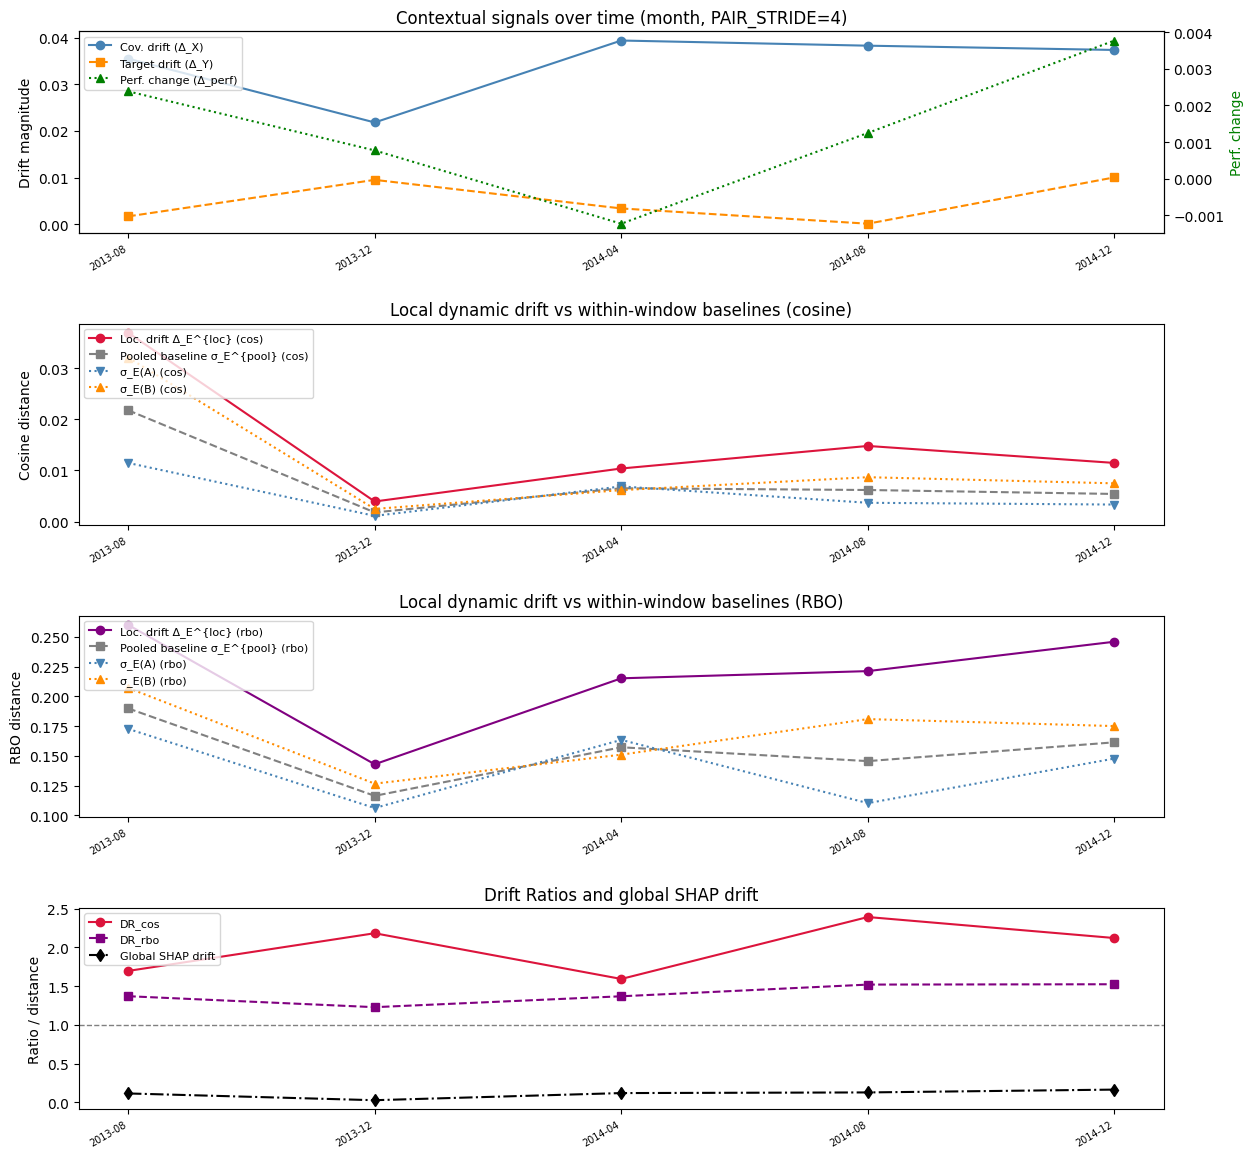

In [6]:
df = drift_df.dropna(subset=['loc_cos'])
x = df['pair_id'].values
x_labels = [f"{r['step_label_A']}" for _, r in df.iterrows()]

fig = plt.figure(figsize=(14, 14))
gs = gridspec.GridSpec(4, 1, hspace=0.45)

ax1 = fig.add_subplot(gs[0])
ax1b = ax1.twinx()
ax1.plot(x, df['delta_X'], 'o-', color='steelblue', label='Cov. drift (Δ_X)')
ax1.plot(x, df['delta_Y'], 's--', color='darkorange', label='Target drift (Δ_Y)')
ax1b.plot(x, df['delta_perf'], '^:', color='green', label='Perf. change (Δ_perf)')
ax1.set_ylabel('Drift magnitude')
ax1b.set_ylabel('Perf. change', color='green')
ax1.set_title(f'Contextual signals over time ({TIME_UNIT}, PAIR_STRIDE={PAIR_STRIDE})')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='upper left', fontsize=8)
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=7)

ax2 = fig.add_subplot(gs[1])
ax2.plot(x, df['loc_cos'], 'o-', color='crimson', label='Loc. drift Δ_E^{loc} (cos)')
ax2.plot(x, df['sigma_cos'], 's--', color='gray', label='Pooled baseline σ_E^{pool} (cos)')
ax2.plot(x, df['base_cos_A'], 'v:', color='steelblue', label='σ_E(A) (cos)')
ax2.plot(x, df['base_cos_B'], '^:', color='darkorange', label='σ_E(B) (cos)')
ax2.set_ylabel('Cosine distance')
ax2.set_title('Local dynamic drift vs within-window baselines (cosine)')
ax2.legend(loc='upper left', fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=7)

ax3 = fig.add_subplot(gs[2])
ax3.plot(x, df['loc_rbo'], 'o-', color='purple', label='Loc. drift Δ_E^{loc} (rbo)')
ax3.plot(x, df['sigma_rbo'], 's--', color='gray', label='Pooled baseline σ_E^{pool} (rbo)')
ax3.plot(x, df['base_rbo_A'], 'v:', color='steelblue', label='σ_E(A) (rbo)')
ax3.plot(x, df['base_rbo_B'], '^:', color='darkorange', label='σ_E(B) (rbo)')
ax3.set_ylabel('RBO distance')
ax3.set_title('Local dynamic drift vs within-window baselines (RBO)')
ax3.legend(loc='upper left', fontsize=8)
ax3.set_xticks(x)
ax3.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=7)

ax4 = fig.add_subplot(gs[3])
ax4.plot(x, df['drift_ratio_cos'], 'o-', color='crimson', label='DR_cos')
ax4.plot(x, df['drift_ratio_rbo'], 's--', color='purple', label='DR_rbo')
ax4.plot(x, df['global_rbo'], 'd-.', color='black', label='Global SHAP drift')
ax4.axhline(1.0, linestyle='--', color='gray', linewidth=1)
ax4.set_ylabel('Ratio / distance')
ax4.set_title('Drift Ratios and global SHAP drift')
ax4.legend(loc='upper left', fontsize=8)
ax4.set_xticks(x)
ax4.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=7)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'drift_summary_over_time.png', dpi=150)
plt.show()

## Per-feature SHAP drift profile

Shows which features shift most in global importance across the timeline.

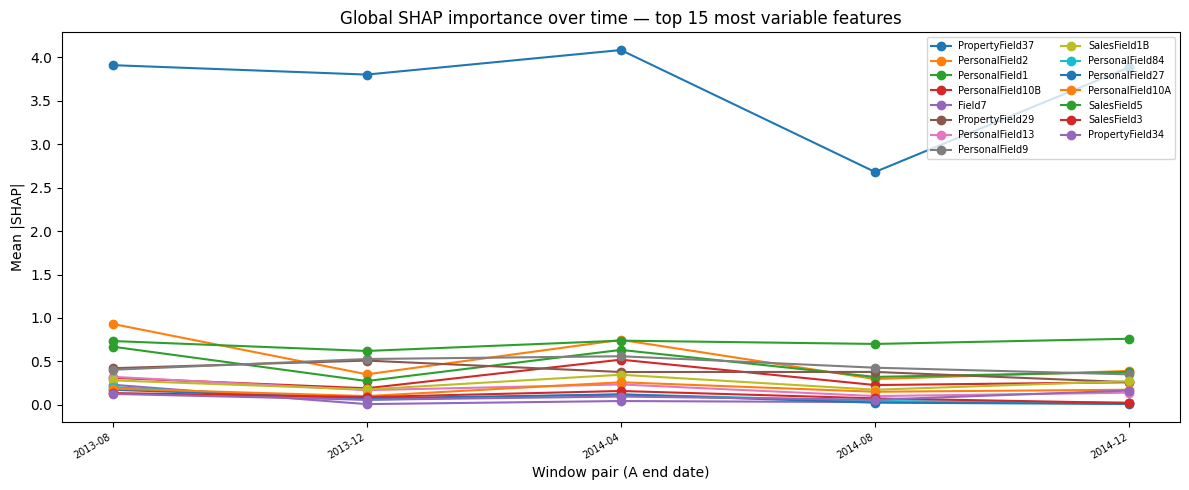

In [7]:
global_imp_matrix = []
pair_labels = []

for p in pairs:
    pid = p['pair_id']
    shap_dir = SHAP_DIR / f'pair_{pid:02d}'
    shap_A_path = shap_dir / 'shap_A.npy'
    if not shap_A_path.exists():
        continue
    shap_A = np.load(shap_A_path)
    phi_bar_A = shap_A.mean(axis=0)
    g_A = np.abs(phi_bar_A).mean(axis=0)
    global_imp_matrix.append(g_A)
    pair_labels.append(p['step_label_A'])

if global_imp_matrix:
    imp_arr = np.array(global_imp_matrix)
    feat_variance = imp_arr.std(axis=0)
    top_feat_idx = np.argsort(-feat_variance)[:15]

    fig, ax = plt.subplots(figsize=(12, 5))
    for j in top_feat_idx:
        ax.plot(range(len(pair_labels)), imp_arr[:, j], marker='o', label=feature_names[j], linewidth=1.5)
    ax.set_title('Global SHAP importance over time — top 15 most variable features')
    ax.set_xlabel('Window pair (A end date)')
    ax.set_ylabel('Mean |SHAP|')
    ax.set_xticks(range(len(pair_labels)))
    ax.set_xticklabels(pair_labels, rotation=30, ha='right', fontsize=7)
    ax.legend(loc='upper right', fontsize=7, ncol=2)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'feature_importance_over_time.png', dpi=150)
    plt.show()
else:
    print('No SHAP files found to build feature-importance profile.')

## Summary statistics

In [8]:
numeric_cols = [
    'pr_auc_A', 'pr_auc_B', 'roc_auc_A', 'roc_auc_B', 'delta_perf',
    'delta_X', 'delta_Y',
    'loc_cos', 'base_cos_A', 'base_cos_B', 'sigma_cos', 'drift_ratio_cos',
    'loc_rbo', 'base_rbo_A', 'base_rbo_B', 'sigma_rbo', 'drift_ratio_rbo',
    'global_rbo', 'shap_stochasticity'
]
summary = drift_df[numeric_cols].describe().T[['mean', 'std', 'min', 'max']]
print('Overall summary:')
print(summary.round(4).to_string())

dr_cos_mean = drift_df['drift_ratio_cos'].mean()
print(f'\n--- Interpretation ---')
print(f'Mean Drift Ratio (cosine): {dr_cos_mean:.3f}')
if dr_cos_mean > 2.0:
    print('Temporal explanation drift is substantially larger than retraining noise.')
elif dr_cos_mean > 1.0:
    print('Temporal drift moderately exceeds retraining baseline.')
else:
    print('Temporal drift is within the range of ordinary retraining noise.')

Overall summary:
                      mean     std     min     max
pr_auc_A            0.8793  0.0213  0.8446  0.9027
pr_auc_B            0.8807  0.0213  0.8459  0.9035
roc_auc_A           0.9584  0.0081  0.9458  0.9672
roc_auc_B           0.9594  0.0076  0.9471  0.9677
delta_perf          0.0014  0.0019 -0.0012  0.0038
delta_X             0.0345  0.0072  0.0218  0.0394
delta_Y             0.0050  0.0046  0.0002  0.0101
loc_cos             0.0155  0.0126  0.0039  0.0369
base_cos_A          0.0053  0.0040  0.0011  0.0115
base_cos_B          0.0114  0.0118  0.0025  0.0321
sigma_cos           0.0083  0.0077  0.0018  0.0218
drift_ratio_cos     1.9968  0.3391  1.5924  2.3919
loc_rbo             0.2171  0.0453  0.1429  0.2601
base_rbo_A          0.1400  0.0305  0.1061  0.1727
base_rbo_B          0.1681  0.0306  0.1266  0.2071
sigma_rbo           0.1541  0.0267  0.1164  0.1899
drift_ratio_rbo     1.4021  0.1236  1.2282  1.5241
global_rbo          0.1103  0.0505  0.0270  0.1639
shap_stochasti